In [ ]:
pip install statsmodels

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
published_data = pd.read_csv("/content/drive/MyDrive/patent_published.csv")

<ipython-input-5-5d07a6cdbabc>:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  published_data = pd.read_csv("/content/drive/MyDrive/patent_published.csv")


In [ ]:
len(published_data)

395162

In [ ]:
published_data.head()

,Unnamed: 0,PUBLICATION_NUMBER,PUBLICATION_DATE,IPO_LOCATION,APPLICATION_TYPE_DESC,APPLICATION_NUMBER,DATE_OF_FILING,TITLE_OF_INVENTION,FIELD_OF_INVENTION,NO_OF_PAGES,NO_OF_CLAIMS
0,0,36/2016,31/08/2016,Delhi,PCT NATIONAL PHASE APPLICATION,6439/DELNP/2011,24/08/2011,SYSTEM FOR NONINVASIVE DETERMINATION OF ALCOHO...,BIOTECHNOLOGY,88,32
1,1,36/2016,31/08/2016,Delhi,PCT NATIONAL PHASE APPLICATION,6442/DELNP/2011,24/08/2011,ELECTRODE PLATE FOR A BATTERY,ELECTRICAL,21,43
2,2,36/2016,31/08/2016,Delhi,PCT NATIONAL PHASE APPLICATION,6498/DELNP/2011,25/08/2011,"""SUBSTITUTED 1,1,3,3-TETRAOXIDOBENZO[D][1,3,2]...",CHEMISTRY,161,159
3,3,36/2016,31/08/2016,Delhi,CONVENTION APPLICATION,652/DEL/2009,31/03/2009,"""PARTITION-FREE MULTI-SOCKET MEMORY SYSTEM ARC...",ELECTRONICS,32,30
4,4,36/2016,31/08/2016,Delhi,CONVENTION APPLICATION,658/DEL/2015,11/03/2015,PROCESS FOR WELDING PIPE CONNECTINS FOR HIGH T...,MECHANICAL,16,10


In [ ]:
published_data.isnull().sum()
published_data.dropna(inplace=True)

In [ ]:
published_data['PUBLICATION_DATE'] = pd.to_datetime(published_data['PUBLICATION_DATE'], dayfirst=True, errors='coerce')

In [ ]:
published_data.set_index('PUBLICATION_DATE', inplace=True)

In [ ]:
# Weekly count of published patents
published_weekly = published_data.resample('W').size().reset_index()
published_weekly.columns = ['Week_Start_Date', 'Published_Count']

In [ ]:
print(published_weekly.head())

  Week_Start_Date  Published_Count
0      2016-01-03              515
1      2016-01-10              212
2      2016-01-17              489
3      2016-01-24              451
4      2016-01-31              290


In [ ]:
import pandas as pd

published_weekly['Week_Start_Date'] = pd.to_datetime(published_weekly['Week_Start_Date'])
published_weekly.set_index('Week_Start_Date', inplace=True)
published_ts = published_weekly['Published_Count']

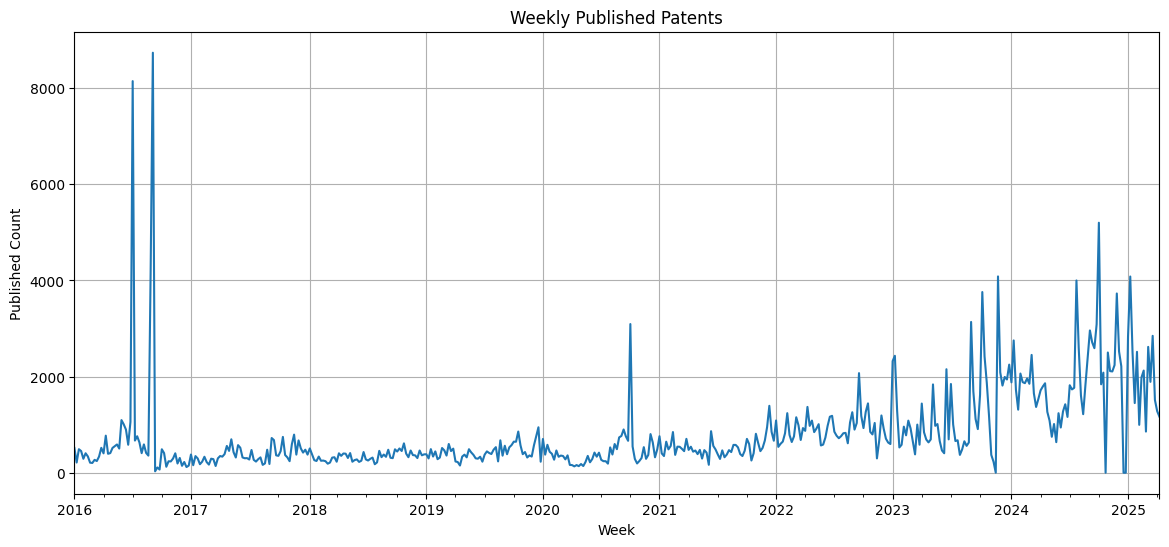

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
published_ts.plot()
plt.title("Weekly Published Patents")
plt.xlabel("Week")
plt.ylabel("Published Count")
plt.grid(True)
plt.show()

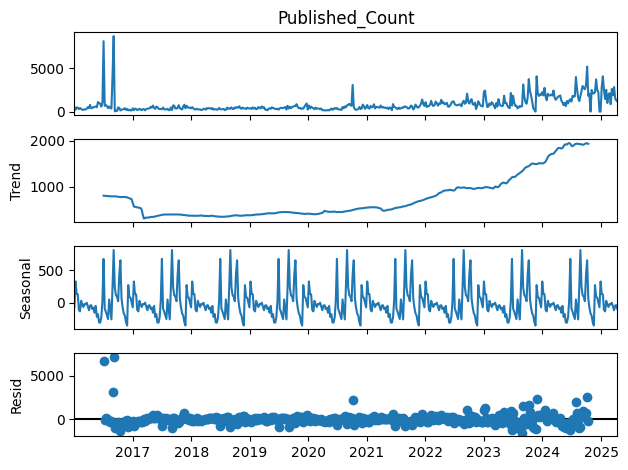

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
decomposition = seasonal_decompose(published_ts, model='additive', period=52)  # Assuming weekly data, period = 52 weeks per year

# Plot the decomposed components
decomposition.plot()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    # Perform the Dickey-Fuller test
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')


check_stationarity(published_ts)

ADF Statistic: -2.3063990356154136
p-value: 0.16991246036633517
Non-Stationary


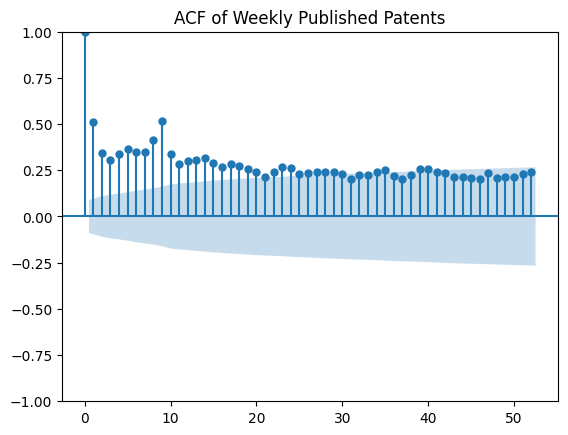

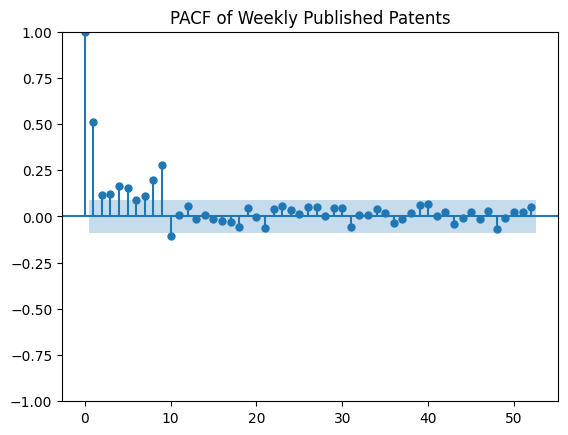

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for granted patent data
plot_acf(published_ts, lags=52)
plt.title('ACF of Weekly Published Patents')
plt.show()

plot_pacf(published_ts, lags=52)
plt.title('PACF of Weekly Published Patents')
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define SARIMA parameters for weekly data
p, d, q = 2, 1, 2
P, D, Q, s = 1, 1, 1, 52
# Fit the SARIMA model
model = SARIMAX(published_ts,
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)

# Fit the model
results = model.fit()

# Summary of the results
print(results.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                      Published_Count   No. Observations:                  485
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 52)   Log Likelihood               -2931.360
Date:                              Wed, 21 May 2025   AIC                           5876.721
Time:                                      08:40:09   BIC                           5904.246
Sample:                                  01-03-2016   HQIC                          5887.646
                                       - 04-13-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4940      0.276     -1.791      0.073      -1.035       0.047
ar.L2          0.20

In [ ]:
# Forecast next 52 weeks
forecast_steps = 52
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual values from the historical data for comparison (use the last part of your data)
actual_values = published_ts[-forecast_steps:]

# Predicted values (forecast mean) for the same period
predicted_values = forecast_mean

# Calculate errors
mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)

# Print the evaluation metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 363.49917317822116
Mean Squared Error (MSE): 191089.81501449083


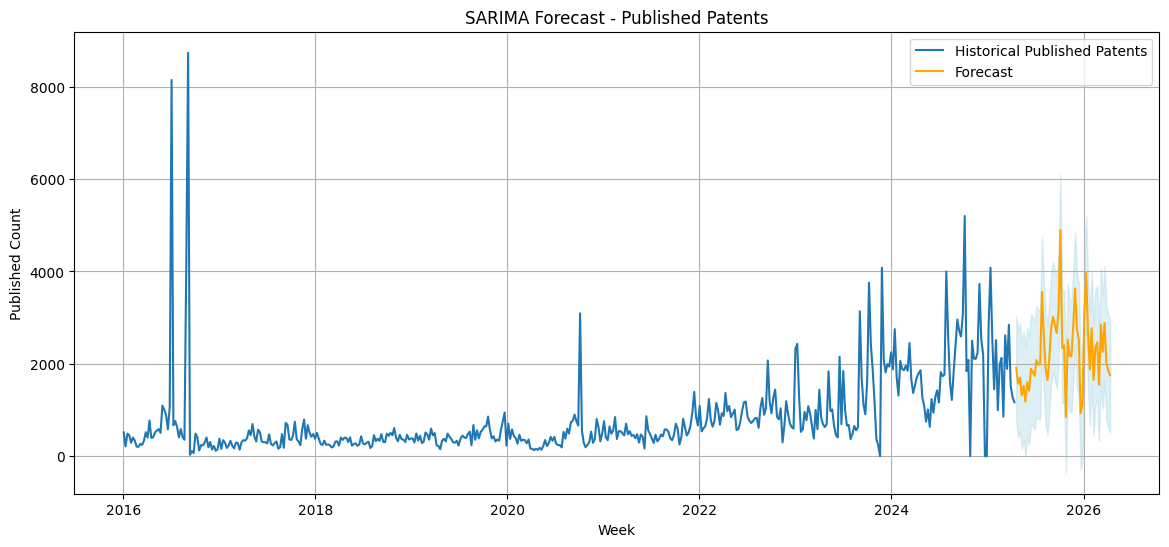

In [ ]:
# Plot the forecast
plt.figure(figsize=(14, 6))
plt.plot(published_ts, label='Historical Published Patents')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='orange')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='lightblue', alpha=0.4)
plt.title("SARIMA Forecast - Published Patents")
plt.xlabel("Week")
plt.ylabel("Published Count")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Display forecasted mean values
print("Forecasted Mean Values for the Next 52 Weeks:")
print(forecast_mean)

# Display confidence intervals (lower and upper bounds)
print("\nConfidence Intervals (Lower and Upper bounds) for the Next 52 Weeks:")
print(forecast_ci)

Forecasted Mean Values for the Next 52 Weeks:
2025-04-20    1916.834447
2025-04-27    1568.390337
2025-05-04    1699.471439
2025-05-11    1315.971665
2025-05-18    1526.364452
2025-05-25    1181.997120
2025-06-01    1601.860352
2025-06-08    1415.672118
2025-06-15    1894.383614
2025-06-22    1820.816276
2025-06-29    1738.856948
2025-07-06    2079.917045
2025-07-13    1980.391968
2025-07-20    1997.317276
2025-07-27    3557.039799
2025-08-03    2584.066163
2025-08-10    1885.067739
2025-08-17    1650.520888
2025-08-24    2120.015171
2025-08-31    2791.722659
2025-09-07    3018.526800
2025-09-14    2840.173784
2025-09-21    2668.493897
2025-09-28    3161.117332
2025-10-05    4899.570310
2025-10-12    2340.963372
2025-10-19    2399.605793
2025-10-26     845.873667
2025-11-02    2523.161112
2025-11-09    2175.724794
2025-11-16    2163.031323
2025-11-23    2837.123678
2025-11-30    3633.490902
2025-12-07    2745.398048
2025-12-14    2518.663752
2025-12-21     929.811492
2025-12-28    1123

In [ ]:
#Outlier Detection
Q1 = published_ts.quantile(0.25)
Q3 = published_ts.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = published_ts[(published_ts < lower_bound) | (published_ts > upper_bound)]
print("\nDetected Outliers:")
print(outliers)


Detected Outliers:
Week_Start_Date
2016-07-03    8147
2016-08-28    4153
2016-09-04    8738
2020-10-04    3093
2022-09-18    2072
2023-01-01    2322
2023-01-08    2433
2023-05-07    1837
2023-06-18    2153
2023-07-02    1846
2023-09-03    3137
2023-10-08    3759
2023-10-15    2420
2023-10-22    1871
2023-11-26    4084
2023-12-03    2089
2023-12-10    1813
2023-12-17    1992
2023-12-24    1940
2023-12-31    2249
2024-01-07    1880
2024-01-14    2752
2024-02-04    2063
2024-02-11    1885
2024-02-18    1863
2024-02-25    1961
2024-03-03    1850
2024-03-10    2451
2024-04-14    1794
2024-04-21    1861
2024-07-07    1820
2024-07-28    4000
2024-08-04    2604
2024-08-25    1824
2024-09-01    2381
2024-09-08    2960
2024-09-15    2714
2024-09-22    2591
2024-09-29    3089
2024-10-06    5201
2024-10-13    1840
2024-10-20    2082
2024-11-03    2501
2024-11-10    2114
2024-11-17    2107
2024-11-24    2240
2024-12-01    3729
2024-12-08    2523
2024-12-15    2215
2025-01-05    2830
2025-01-12    

In [ ]:
# Replace outliers with the median (a robust measure)
median_val_p = published_ts.median()
published_ts_cleaned = published_ts.copy()
published_ts_cleaned[(published_ts_cleaned < lower_bound) | (published_ts_cleaned > upper_bound)] = median_val_p

In [ ]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')
    return p_value

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define SARIMA parameters for weekly data
p, d, q = 2, 1, 1
P, D, Q, s = 1, 1, 1, 52
# Fit the SARIMA model
model = SARIMAX(published_ts_cleaned,
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)

# Fit the model
results = model.fit()

# Summary of the results
print(results.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                    Published_Count   No. Observations:                  485
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 52)   Log Likelihood               -2670.596
Date:                            Wed, 21 May 2025   AIC                           5353.191
Time:                                    08:41:14   BIC                           5376.801
Sample:                                01-03-2016   HQIC                          5362.562
                                     - 04-13-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1701      0.055      3.067      0.002       0.061       0.279
ar.L2         -0.0531      0.048   

In [ ]:
# Forecast next 52 weeks
forecast_steps = 52
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual values from the historical data for comparison (use the last part of your data)
actual_values = published_ts_cleaned[-forecast_steps:]

# Predicted values (forecast mean) for the same period
predicted_values = forecast_mean

# Calculate errors
mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)

# Print the evaluation metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 342.97281005727734
Mean Squared Error (MSE): 157567.62713311138


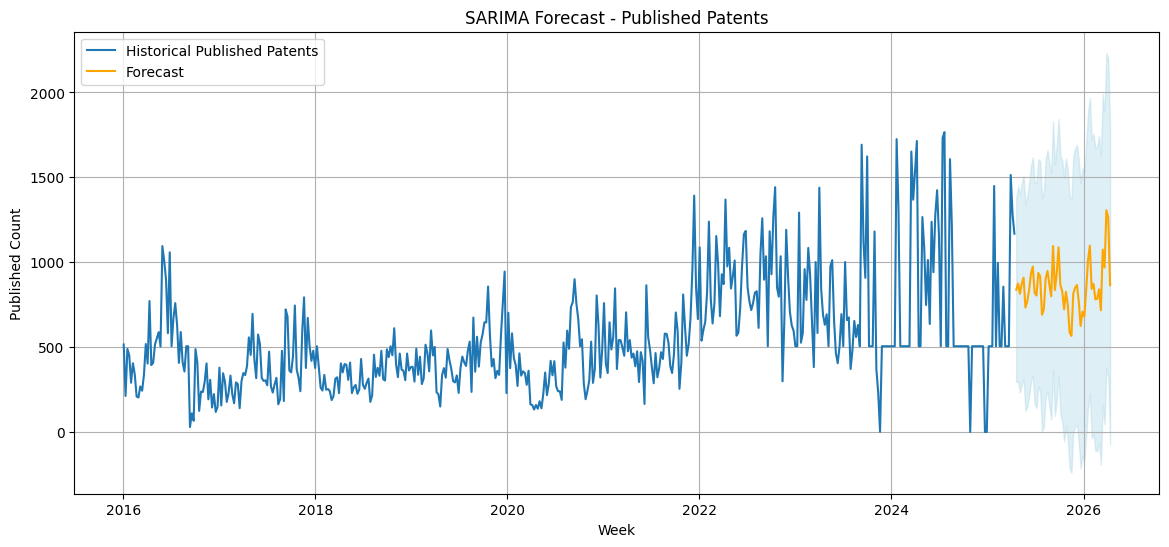

In [ ]:
# Plot the forecast
plt.figure(figsize=(14, 6))
plt.plot(published_ts_cleaned, label='Historical Published Patents')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='orange')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='lightblue', alpha=0.4)
plt.title("SARIMA Forecast - Published Patents")
plt.xlabel("Week")
plt.ylabel("Published Count")
plt.legend()
plt.grid(True)
plt.show()